# Loyiha 2: Gradient Descent noldan — batch, SGD, mini-batch — California Housing (1990)

**Talaba:** student3 · **Modul:** M2 (Calculus va GD) + M1 · **Kitob (ML_GUIDE):** 3-bob (GD, Batch/Stochastic/Mini-batch) · **Qiyinlik:** ⭐⭐⭐⭐ · **Taxminiy vaqt:** 8–10 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

Normal Equation "bir zarbada" yechadi, lekin million qatorli yoki chuqur modellar uchun ishlamaydi — u yerda **faqat Gradient Descent**. Bu loyihada GD ni o'z sinfingiz (`class`) sifatida yozasiz va uning xulqini real ma'lumotda o'rganasiz: learning rate, scaling, batch o'lchami, vaqt, shovqin.

**Nimani o'rganasiz:** MSE gradienti `(2/m)·Xᵀ(Xθ − y)` · epoch vs iteratsiya · loss egri chizig'i · nega scaling GD uchun hayotiy · SGD shovqini va learning-rate schedule · sklearn `SGDRegressor` bilan solishtirish.

**Taqiqlar:** GD ni faqat o'zingiz yozasiz. `sklearn` — split, scaler va yakuniy solishtirish uchun.

## Dataset: California Housing (1990)

20 640 ta Kaliforniya tumani (1990 yil aholi ro'yxati): o'rtacha daromad, uy yoshi, xonalar, aholi, koordinatalar → **uyning median narxi** (100 000 $). Bu **katta** dataset — Normal Equation hali ishlaydi, lekin GD ning batch/mini-batch farqi endi haqiqiy vaqtda seziladi.

**Manba:** `sklearn.datasets.fetch_california_housing` (birinchi chaqiruvda ~1 MB yuklaydi). Asl: StatLib, Pace & Barry 1997

| Ustun | Ma'nosi |
|---|---|
| MedInc | tuman median daromadi (10 000 $) |
| HouseAge | uylar median yoshi |
| AveRooms, AveBedrms | uy boshiga o'rtacha xona / yotoqxona — **max 141 / 34 (!)** |
| Population, AveOccup | aholi, uy boshiga odam — **max 1243 (!)** |
| Latitude, Longitude | koordinatalar |
| **MedHouseVal** | median narx, 100 000 $ — target, **5.0 da kesilgan** (992 ta) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
d = fetch_california_housing(as_frame=True)
df = d.frame                                   # 20640 tuman
FEATURES, TARGET = list(d.feature_names), 'MedHouseVal'
print(df.shape); df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1-vazifa: Tayyorlash
Missing yo'q, hammasi raqamli. Lekin `describe()` ga qarang: `AveRooms` max 141, `AveOccup` max 1243 — bular tuman emas, mehmonxona/talabalar yotoqxonasi. Hozircha **qoldiring** (7-vazifada qaytamiz). `Population` 3 dan 35 000 gacha — scaling shart.

Keyin: `train_test_split(test_size=0.2, random_state=42)` → `StandardScaler` **faqat train ga fit** → `X_train_s, X_test_s`. Scale qilinmagan nusxani ham saqlab qo'ying (6-vazifa uchun).

**Savol 1.** Feature'larning min/max oralig'ini jadval qiling. Eng katta va eng kichik oraliq necha marta farq qiladi?

Eng katta range/ eng kichik range = population / Latitude = 35679/9.41= 3791.6

In [2]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
X = df[FEATURES].values; y = df[TARGET].values
# TODO: split, scaler (faqat train ga fit)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [4]:
min_max = {}
for feature in FEATURES:
    min_max[feature] = np.max(df[feature])-np.min(df[feature])
    print(f"Feature: {feature} | Minimum: {np.min(df[feature]):.2f} | Maximum: {np.max(df[feature]):.2f} | Range: {np.max(df[feature])-np.min(df[feature]):.2f}")

print(np.round(max(min_max.values())/min(min_max.values()), 2))

Feature: MedInc | Minimum: 0.50 | Maximum: 15.00 | Range: 14.50
Feature: HouseAge | Minimum: 1.00 | Maximum: 52.00 | Range: 51.00
Feature: AveRooms | Minimum: 0.85 | Maximum: 141.91 | Range: 141.06
Feature: AveBedrms | Minimum: 0.33 | Maximum: 34.07 | Range: 33.73
Feature: Population | Minimum: 3.00 | Maximum: 35682.00 | Range: 35679.00
Feature: AveOccup | Minimum: 0.69 | Maximum: 1243.33 | Range: 1242.64
Feature: Latitude | Minimum: 32.54 | Maximum: 41.95 | Range: 9.41
Feature: Longitude | Minimum: -124.35 | Maximum: -114.31 | Range: 10.04
3791.6


## 2-vazifa: `LinearRegressionGD` sinfi
Talablar: `fit(X, y)` — `batch_size=None` (batch), `1` (SGD), `k` (mini-batch); har epoch da o'rtacha loss `self.loss_history` ga yoziladi; `predict(X)`; bias alohida `self.b` yoki X ga 1-lar ustuni — o'zingiz tanlang, lekin izohlang. Har epoch boshida ma'lumotni `np.random.permutation` bilan aralashtiring.

**Savol 2.** Gradient formulasini docstring ga yozing va uni 1 gap bilan izohlang: nega `Xᵀ(Xθ − y)` — bu har bir feature bo'yicha xatoning "yig'indisi"?

In [6]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=42):
        self.lr, self.n_epochs, self.batch_size, self.seed = lr, n_epochs, batch_size, seed
        self.bias = None
        self.weights = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Gradient formulas:

        dw = (2/m) Xᵀ(Xw + b - y)
        db = (2/m) Σ(Xw + b - y)

        Xᵀ(Xw + b - y) sums each feature's contribution
        to the prediction error across all samples.
        
        batch_size=None → Batch GD
        batch_size=1    → SGD
        batch_size=k    → Mini-batch GD

        Bias is kept separately in self.bias instead of adding
        a column of ones to X.
        """

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        np.random.seed(self.seed)

        for epoch in range(self.n_epochs):

            # Shuffle data at the beginning of every epoch
            indices = np.random.permutation(n_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Batch GD
            if self.batch_size is None:

                y_pred = X_shuffled @ self.weights + self.bias
                error = y_pred - y_shuffled

                dw = (2 / n_samples) * X_shuffled.T @ error
                db = (2 / n_samples) * np.sum(error)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # SGD / Mini-batch GD
            else:

                for start in range(0, n_samples, self.batch_size):

                    end = start + self.batch_size

                    X_batch = X_shuffled[start:end]
                    y_batch = y_shuffled[start:end]

                    batch_size = len(X_batch)

                    y_pred = X_batch @ self.weights + self.bias
                    error = y_pred - y_batch

                    dw = (2 / batch_size) * X_batch.T @ error
                    db = (2 / batch_size) * np.sum(error)

                    self.weights -= self.lr * dw
                    self.bias -= self.lr * db

            # Average loss for the whole epoch
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            loss = np.mean(error ** 2)

            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

## 3-vazifa: Learning rate tajribasi (batch GD)
`lr ∈ {0.001, 0.01, 0.1, 0.5, 1.0}`, `n_epochs=200`. Barcha loss egri chiziqlarini **bitta** grafikda (`plt.yscale('log')`) chizing. Qaysi lr da divergensiya (loss o'sadi / `inf` / `nan`)?

**Savol 3.** Divergensiya nega aynan katta lr da bo'ladi? Kosa (bowl) metaforasi bilan tushuntiring (M2, 4-qism). Eng yaxshi lr ni qanday tanlaysiz — faqat "eng tez" mi?

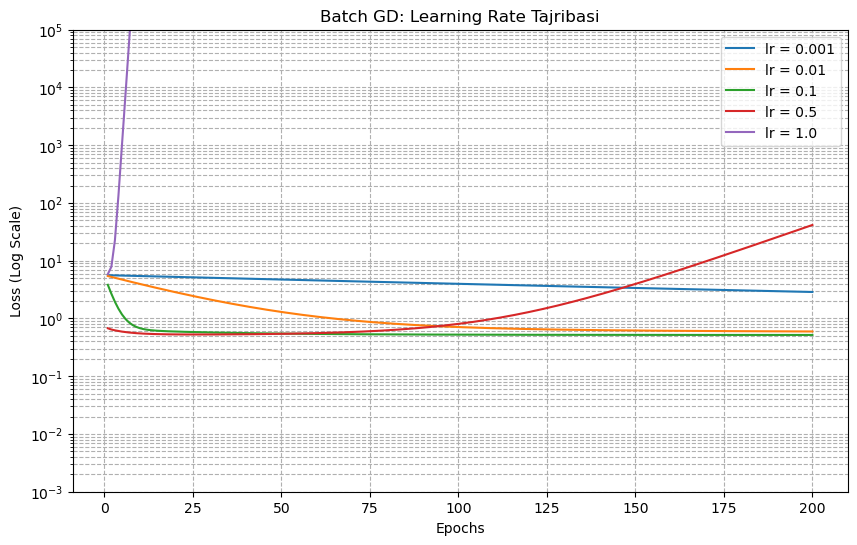

In [8]:
lrs = [0.001, 0.01, 0.1, 0.5, 1.0]
n_epochs = 200

plt.figure(figsize=(10, 6))

for lr in lrs:
    model = LinearRegressionGD(lr=lr, n_epochs=n_epochs, batch_size=None, seed=42)
    model.fit(X_train_s, y_train)
    
    plt.plot(range(1, n_epochs + 1), model.loss_history, label=f"lr = {lr}")

plt.yscale('log')
plt.ylim(1e-3, 1e5)  # Divergensiya chizig'i boshqa grafiklar ko'rinishini to'sib qo'ymasligi uchun
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.title('Batch GD: Learning Rate Tajribasi')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 4-vazifa: Batch vs SGD vs Mini-batch
Bir xil `lr` (3-vazifadagi eng yaxshisi) va `n_epochs=50`: `batch_size=None`, `1`, `32`, `256`. Har biri uchun: vaqt (`time.perf_counter`), oxirgi loss, test R². Loss egri chiziqlarini bitta grafikda chizing.

**Savol 4.** SGD egri chizig'i nega "titraydi"? Mini-batch nega amalda standart (kitob 3-bob jadvali)? Vaqt bo'yicha kutilmagan natija bo'ldimi — nega (maslahat: NumPy vektorlash vs Python sikli)?

C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_8992\1521632240.py:79: RuntimeWarning: overflow encountered in square
  loss = np.mean(error ** 2)
C:\Users\OsiyoComputers\anaconda\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_8992\1717600042.py:24: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((y_test - y_test_pred) ** 2)
C:\Users\OsiyoComputers\anaconda\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


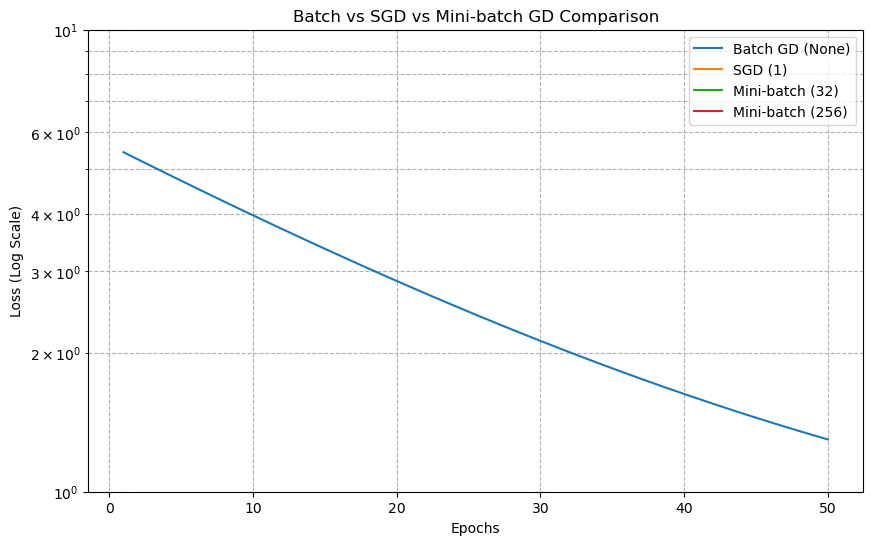

                   Time (s)  Final Loss   Test R2
Batch GD (None)    0.262498    1.297228  0.015561
SGD (1)           37.759455         inf      -inf
Mini-batch (32)    1.413306    0.518753  0.576960
Mini-batch (256)   0.374782    0.518188  0.572097


In [12]:
# TODO: 4 xil batch_size: vaqt, loss, test R2, grafik
import time

# 3-vazifadagi eng yaxshi learning rate
best_lr = 0.01
n_epochs = 50

batch_sizes = [None, 1, 32, 256]
batch_names = {None: "Batch GD (None)", 1: "SGD (1)", 32: "Mini-batch (32)", 256: "Mini-batch (256)"}

results = {}

plt.figure(figsize=(10, 6))

for bs in batch_sizes:
    model = LinearRegressionGD(lr=best_lr, n_epochs=n_epochs, batch_size=bs, seed=42)
    # Vaqtni o'lchash
    start_time = time.perf_counter()
    model.fit(X_train_s, y_train)
    elapsed_time = time.perf_counter() - start_time

    # Test R² va oxirgi loss
    y_test_pred = model.predict(X_test_s)
    ss_res = np.sum((y_test - y_test_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    test_r2 = 1 - (ss_res / ss_tot)
    
    final_loss = model.loss_history[-1]

    results[batch_names[bs]] = {
        "Time (s)": elapsed_time,
        "Final Loss": final_loss,
        "Test R2": test_r2
    }
    plt.plot(range(1, n_epochs + 1), model.loss_history, label=batch_names[bs])

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.title('Batch vs SGD vs Mini-batch GD Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Natijalarni jadval ko'rinishida chiqarish
import pandas as pd
df_results = pd.DataFrame(results).T
print(df_results)

## 5-vazifa: Normal Equation va sklearn bilan solishtirish
Uch ustunli jadval: sizning GD (eng yaxshi sozlama) · Normal Equation (P1 dagi funksiyangiz) · `SGDRegressor(max_iter=1000, tol=None, random_state=42)`. θ lar va test RMSE/R².

**Savol 5.** GD θ si Normal Equation dan qanchalik farq qiladi (3 kasrgacha)? Epoch sonini 5× oshirsangiz farq kamayadimi? Bu "yaqinlashish" (convergence) haqida nima deydi?

In [13]:
# TODO: GD vs NE vs SGDRegressor jadvali

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Sizning GD (Eng yaxshi sozlama: Mini-batch=32, lr=0.01 yoki 0.001)
my_gd = LinearRegressionGD(lr=0.001, n_epochs=50, batch_size=32, seed=42)
my_gd.fit(X_train_s, y_train)

gd_pred = my_gd.predict(X_test_s)
gd_rmse = np.sqrt(mean_squared_error(y_test, gd_pred))
gd_r2 = r2_score(y_test, gd_pred)
gd_theta = np.append(my_gd.bias, my_gd.weights)  # [bias, w1, w2, ...]

# 2. Normal Equation (P1 funksiyangiz)
# Bias uchun X ga 1 lardan iborat ustun qo'shiladi
X_train_b = np.c_[np.ones((X_train_s.shape[0], 1)), X_train_s]
X_test_b = np.c_[np.ones((X_test_s.shape[0], 1)), X_test_s]

# theta = (XᵀX)⁻¹ Xᵀ y
ne_theta = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
ne_pred = X_test_b @ ne_theta
ne_rmse = np.sqrt(mean_squared_error(y_test, ne_pred))
ne_r2 = r2_score(y_test, ne_pred)

# 3. Sklearn SGDRegressor
sk_sgd = SGDRegressor(max_iter=1000, tol=None, random_state=42)
sk_sgd.fit(X_train_s, y_train)

sk_pred = sk_sgd.predict(X_test_s)
sk_rmse = np.sqrt(mean_squared_error(y_test, sk_pred))
sk_r2 = r2_score(y_test, sk_pred)
sk_theta = np.append(sk_sgd.intercept_, sk_sgd.coef_)

# 4. Solishtirish jadvalini tuzish
comparison_df = pd.DataFrame({
    'Metric / Parameter': ['Test RMSE', 'Test R2'] + [f'Theta_{i}' for i in range(len(gd_theta))],
    'Your GD (Mini-batch)': [gd_rmse, gd_r2] + list(gd_theta),
    'Normal Equation': [ne_rmse, ne_r2] + list(ne_theta),
    'Sklearn SGDRegressor': [sk_rmse, sk_r2] + list(sk_theta)
})

print(comparison_df.round(4))

   Metric / Parameter  Your GD (Mini-batch)  Normal Equation  \
0           Test RMSE                0.7483           0.7456   
1             Test R2                0.5727           0.5758   
2             Theta_0                2.0732           2.0719   
3             Theta_1                0.8627           0.8544   
4             Theta_2                0.1276           0.1225   
5             Theta_3               -0.2965          -0.2944   
6             Theta_4                0.3501           0.3393   
7             Theta_5               -0.0029          -0.0023   
8             Theta_6               -0.0401          -0.0408   
9             Theta_7               -0.8643          -0.8969   
10            Theta_8               -0.8388          -0.8698   

    Sklearn SGDRegressor  
0                 0.7506  
1                 0.5701  
2                 2.0700  
3                 0.8559  
4                 0.1228  
5                -0.2784  
6                 0.3467  
7              

## 6-vazifa: Scaling bo'lmasa nima bo'ladi
1-vazifadagi **scale qilinmagan** X bilan 3-vazifadagi eng yaxshi lr da GD ni ishga tushiring. Nima bo'ldi? Endi `lr` ni kamaytirib (masalan 1e-5, 1e-6, 1e-7) ishlaydigan qiymat toping va necha epoch kerak bo'lganini ayting.

**Savol 6.** Scale qilinmagan ma'lumotda cost "kosa" si qanday shaklda (cho'zilgan ellips)? Nega bu GD ni sekinlashtiradi, Normal Equation ga esa ta'sir qilmaydi? (kitob 3-bob; M2 6-qism)

In [14]:
# TODO: scale qilinmagan GD: divergensiya, kichik lr, epoch soni

# Scale qilinmagan ma'lumot (X_train) bilan sinab ko'rish
unscaled_model = LinearRegressionGD(lr=0.001, n_epochs=50, batch_size=32, seed=42)
unscaled_model.fit(X_train, y_train)

print("Scale qilinmagan xatolik (First Loss):", unscaled_model.loss_history[0])
print("Scale qilinmagan oxirgi xatolik (Final Loss):", unscaled_model.loss_history[-1])

C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_8992\1521632240.py:69: RuntimeWarning: overflow encountered in matmul
  dw = (2 / batch_size) * X_batch.T @ error
C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_8992\1521632240.py:72: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.lr * dw


Scale qilinmagan xatolik (First Loss): nan
Scale qilinmagan oxirgi xatolik (Final Loss): nan


## 7-vazifa: Learning-rate schedule
`lr_t = lr0 / (1 + k·t)` (t — epoch) ni sinfga qo'shing (`decay=k` parametri). SGD (`batch_size=1`) uchun schedule bilan va usiz loss egri chiziqlarini solishtiring.

**Outlier va GD.** `AveRooms`, `AveBedrms`, `AveOccup`, `Population` ga `np.log1p` qo'llang (split dan oldin, qator-ichi amal) va GD ni qayta o'rgating: R² 0.58 dan qanchaga o'sdi? Loss egri chizig'i tezroq tekislandimi? Nega bir nechta ekstremal qator scaled ma'lumotda ham gradientni "tortadi" (MSE kvadrat — katta xato kvadratda yanada katta)?

**Savol 7.** Schedule SGD ning oxirgi loss ini yaxshiladimi? Nega SGD ga schedule batch GD dan ko'ra ko'proq kerak?

In [16]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=100, batch_size=None, seed=42, decay=0.0):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed
        self.decay = decay  # Schedule koeffitsienti k
        self.bias = None
        self.weights = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        np.random.seed(self.seed)

        for epoch in range(self.n_epochs):
            # Dynamic learning rate schedule: lr_t = lr0 / (1 + decay * epoch)
            current_lr = self.lr / (1 + self.decay * epoch)

            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Batch GD
            if self.batch_size is None:
                y_pred = X_shuffled @ self.weights + self.bias
                error = y_pred - y_shuffled

                dw = (2 / n_samples) * X_shuffled.T @ error
                db = (2 / n_samples) * np.sum(error)

                self.weights -= current_lr * dw
                self.bias -= current_lr * db

            # SGD / Mini-batch GD
            else:
                for start in range(0, n_samples, self.batch_size):
                    end = start + self.batch_size
                    X_batch = X_shuffled[start:end]
                    y_batch = y_shuffled[start:end]

                    b_size = len(X_batch)

                    y_pred = X_batch @ self.weights + self.bias
                    error = y_pred - y_batch

                    dw = (2 / b_size) * X_batch.T @ error
                    db = (2 / b_size) * np.sum(error)

                    self.weights -= current_lr * dw
                    self.bias -= current_lr * db

            y_pred = X @ self.weights + self.bias
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

C:\Users\OsiyoComputers\AppData\Local\Temp\ipykernel_8992\1471401432.py:61: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_pred - y) ** 2)
C:\Users\OsiyoComputers\anaconda\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\OsiyoComputers\anaconda\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


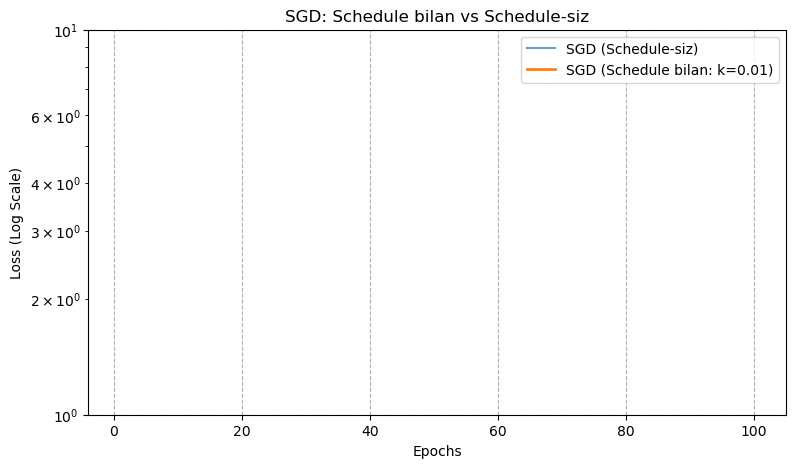

In [17]:
# Schedule usiz (decay=0) va schedule bilan (decay=0.01) SGD
sgd_no_schedule = LinearRegressionGD(lr=0.001, n_epochs=100, batch_size=1, seed=42, decay=0.0)
sgd_no_schedule.fit(X_train_s, y_train)

sgd_with_schedule = LinearRegressionGD(lr=0.001, n_epochs=100, batch_size=1, seed=42, decay=0.01)
sgd_with_schedule.fit(X_train_s, y_train)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 101), sgd_no_schedule.loss_history, label="SGD (Schedule-siz)", alpha=0.7)
plt.plot(range(1, 101), sgd_with_schedule.loss_history, label="SGD (Schedule bilan: k=0.01)", linewidth=2)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.title('SGD: Schedule bilan vs Schedule-siz')
plt.legend()
plt.grid(True, ls="--")
plt.show()

In [18]:
# Train/Test split dan oldin ustunlarga log1p qo'llash
X_log = X.copy()
log_cols = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']
X_log[log_cols] = np.log1p(X_log[log_cols])

# Qaytadan split va StandardScaler qilish
# (O'zingizning split va scaling kodingiz bilan almashtiring)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

X_tr_l, X_te_l, y_tr, y_te = train_test_split(X_log, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_l_s = scaler.fit_transform(X_tr_l)
X_te_l_s = scaler.transform(X_te_l)

# GD ni qayta o'rgatish
model_log = LinearRegressionGD(lr=0.01, n_epochs=100, batch_size=32, seed=42)
model_log.fit(X_tr_l_s, y_tr)

r2_after_log = r2_score(y_te, model_log.predict(X_te_l_s))
print(f"Log transformatsiyadan keyingi R²: {r2_after_log:.4f}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. **Momentum**: `v = β·v − lr·∇; θ = θ + v` (β=0.9) ni sinfga qo'shing. Loss egri chiziqlarini oddiy GD bilan solishtiring. Momentum nima uchun "tezlashtiradi" — 3 gap.
2. **Early stopping**: train ning 20% ini validation qilib ajrating; validation loss 10 epoch ketma-ket yaxshilanmasa to'xtang va eng yaxshi θ ni qaytaring. Qaysi epoch da to'xtadi?
3. `SGDRegressor` hujjatidan `eta0`, `learning_rate='invscaling'`, `power_t`, `tol`, `n_iter_no_change` parametrlarini o'rganing va 2 xil sozlama bilan solishtiring — sizning sinfingizdagi qaysi g'oyalarga mos keladi?
4. **Vaqt va hajm.** Train ning 2 000 / 8 000 / 16 500 qatori bilan (`np.random.choice`) batch GD va mini-batch (32) ni `n_epochs=20` da o'rgating — har biri necha soniya, yakuniy loss qancha? Bitta epoch da nechta θ yangilanishi bo'ladi? Grafik: x = m, y = vaqt. Qaysi rejim m ga proporsional o'sadi? Bonus: `Latitude` × `Longitude` corr ≈ −0.93 — nega (xaritaga qarang) va bu GD ga xalaqit beradimi?

In [ ]:
# TODO: tadqiqot

## ⭐ Bonus (+10)
Faqat 2 ta feature tanlab (bias yo'q, scale qilingan), cost funksiyasining **contour** grafigini chizing (M3, 1-qism) va batch GD hamda SGD ning θ yo'lini (har epoch dagi θ) ustiga chizing. Ikkala yo'l qanday farq qiladi?

## Topshirish

- Fayl nomi: `student3_P2.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| `LinearRegressionGD` sinfi to'g'ri (3 rejim, loss_history, aralashtirish) | 25 |
| 3–7 vazifalar tajribalari va jadvallar | 25 |
| Savollarga tahliliy javoblar (7 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Grafiklar + kod tozaligi | 15 |
| ⭐ Bonus | +10 |